In [ ]:
# --------------------------------------------------------------------------
# Libraries
# --------------------------------------------------------------------------
install.packages("skimr")
install.packages("DataExplorer")
install.packages("corrplot")
install.packages(c("mlr3verse", "mlr3", "mlr3learners", "mlr3pipelines", 
                   "mlr3viz", "mlr3tuning", "DALEX", "iml"))

install.packages("mlr3")
install.packages("mlr3tuning")
install.packages("mlr3learners")
install.packages("mlr3pipelines")
install.packages("paradox")
install.packages("DALEX")
install.packages("ggpubr")
install.packages("DALEXtra")  # if not installed
library(DALEXtra)


library(data.table)
library(tidyverse)
library(skimr)
library(DataExplorer)
library(lubridate)
library(corrplot)
library(ggplot2)
library(ggpubr)
library(mlr3)
library(mlr3verse)
library(mlr3tuning)
library(mlr3learners)
library(mlr3viz)
library(xgboost)
library(DALEX)
library(iml)
# Install the patchwork package
install.packages("patchwork")

# Load the patchwork library
library(patchwork)

In [ ]:


# --------------------------------------------------------------------------
# Loading Data
# --------------------------------------------------------------------------



#data <- read.csv("F:/University/Lecture Materials/Erasmus Denmark/Interpretable Machine Learning/Project 1/Motor vehicle insurance data.csv", sep = ";")
data <- read.csv("Dataset of an actual motor vehicle insurance portfolio/Motor vehicle insurance data.csv", sep = ";")
summary(data)


glimpse(data)

#skim(data)

# Ensure the data is valid before plotting missing values
# if (exists("data") && is.data.frame(data)) {
# plot_missing(data)
# } else {
# warning("Data is not available or not a valid data frame.")
# }
# --------------------------------------------------------------------------
# Preprocessing Data
# --------------------------------------------------------------------------
## Cleaning

# --------------------------------------------------------------------------
data <- data %>%
  mutate(
    Date_start_contract = dmy(Date_start_contract),
    Date_last_renewal = dmy(Date_last_renewal),
    Date_next_renewal = dmy(Date_next_renewal),
    Date_birth = dmy(Date_birth),
    Date_driving_licence = dmy(Date_driving_licence),
    Date_lapse = ifelse(Date_lapse == "", NA, Date_lapse),
    Date_lapse = dmy(Date_lapse),

    Distribution_channel = as.factor(Distribution_channel),
  )

str(data)

preprocess_data <- function(data) {
  df_processed <- data %>%

    # date of birth → age
    mutate(Age = as.integer(floor(interval(Date_birth, Date_start_contract) / years(1)))) %>%

    # date of driving licence → year of driving experience
    mutate(Driving_experience = as.integer(floor(interval(Date_driving_licence, Date_start_contract) / years(1)))) %>%

    # Lapse → Nan → 0
    mutate(Lapse = ifelse(is.na(Lapse), 0, Lapse)) %>%

    # Date_lapse → Time remained until the end of contract
    mutate(
      Lapse_duration_days = as.numeric(Date_lapse - Date_start_contract)
    ) %>%

    mutate(
    Lapse_duration_days = ifelse(Lapse == 0, 0, Lapse_duration_days),
    Has_lapsed = ifelse(Lapse == 0, 0, 1)
    ) %>%

    mutate(
    Lapse_duration_days = replace_na(Lapse_duration_days, 0),
    Has_lapsed = replace_na(Has_lapsed, 0)) %>%

    # car_age
    mutate(Car_age = as.integer(year(Date_start_contract)) - as.integer(Year_matriculation)) %>%

    group_by(Type_risk) %>%
    mutate(Type_fuel = ifelse(is.na(Type_fuel),
                              names(sort(table(Type_fuel), decreasing = TRUE))[1],
                              Type_fuel)) %>%
    ungroup() %>%
    mutate(
      Fuel_Petrol = ifelse(Type_fuel == "P", 1, 0),
      Fuel_Diesel = ifelse(Type_fuel == "D", 1, 0)
    ) %>%

    mutate(Distribution_channel = ifelse(is.na(Distribution_channel), "Missing", Distribution_channel)) %>%
    mutate(Distribution_channel = as.factor(Distribution_channel)) %>%

    # Length
    group_by(Type_risk) %>%
    mutate(
      Length = ifelse(is.na(Length), mean(Length, na.rm = TRUE), Length)
    ) %>%
    ungroup()

  return(df_processed)
}

processed_df <- preprocess_data(data)
head(processed_df)

#skim(processed_df)

df_weighted <- processed_df %>%
  mutate(Duration_days = pmin(Date_next_renewal, Date_lapse, na.rm = TRUE) - Date_start_contract) %>%
  mutate(Contract_duration = Duration_days / 365)

names(df_weighted)

get_mode <- function(x) {
  ux <- unique(x)
  ux[which.max(tabulate(match(x, ux)))]
}

df_agg <- df_weighted %>%
  group_by(ID) %>%
  summarise(
    Cost_claims_year = weighted.mean(Cost_claims_year, as.numeric(Contract_duration), na.rm = TRUE),
    Age = first(Age),
    Driving_experience = first(Driving_experience),
    Seniority = last(Seniority),
    Policies_in_force = last(Policies_in_force),
    Max_policies = max(Max_policies),
    Max_products = max(Max_products),
    Payment = get_mode(Payment),
    N_claims_year = last(N_claims_year),
    N_claims_history = last(N_claims_history),
    R_Claims_history = mean(R_Claims_history),
    Contract_duration = last(Contract_duration),
    Car_age = first(Car_age),
    Fuel_Petrol = max(Fuel_Petrol),
    Fuel_Diesel = max(Fuel_Diesel),
    Distribution_channel = first(Distribution_channel),
    Type_risk = first(Type_risk),
    Area = first(Area),
    Second_driver = max(Second_driver),
    Power = mean(Power, na.rm = TRUE),
    Cylinder_capacity = mean(Cylinder_capacity, na.rm = TRUE),
    Value_vehicle = mean(Value_vehicle, na.rm = TRUE),
    Length = mean(Length, na.rm = TRUE),
    Weight = mean(Weight, na.rm = TRUE),
    N_doors = first(N_doors)
  ) %>%
  ungroup()

head(df_agg)

#skim(df_agg)

df_model <- df_agg


set.seed(42)
df_model <- df_agg %>% select(-ID)
df_model$Cost_claims_year <- as.numeric(df_model$Cost_claims_year)
df_model <- df_model %>%
  mutate(across(where(~ inherits(.x, "difftime")), as.numeric))
head(df_model)



Pobrane pakiety binarne są w
	/var/folders/q7/p3s6dfbn0dv04bh3j4kgrz2c0000gn/T//RtmpqoHLve/downloaded_packages

Pobrane pakiety binarne są w
	/var/folders/q7/p3s6dfbn0dv04bh3j4kgrz2c0000gn/T//RtmpqoHLve/downloaded_packages

Pobrane pakiety binarne są w
	/var/folders/q7/p3s6dfbn0dv04bh3j4kgrz2c0000gn/T//RtmpqoHLve/downloaded_packages

Pobrane pakiety binarne są w
	/var/folders/q7/p3s6dfbn0dv04bh3j4kgrz2c0000gn/T//RtmpqoHLve/downloaded_packages

Pobrane pakiety binarne są w
	/var/folders/q7/p3s6dfbn0dv04bh3j4kgrz2c0000gn/T//RtmpqoHLve/downloaded_packages

Pobrane pakiety binarne są w
	/var/folders/q7/p3s6dfbn0dv04bh3j4kgrz2c0000gn/T//RtmpqoHLve/downloaded_packages

Pobrane pakiety binarne są w
	/var/folders/q7/p3s6dfbn0dv04bh3j4kgrz2c0000gn/T//RtmpqoHLve/downloaded_packages

Pobrane pakiety binarne są w
	/var/folders/q7/p3s6dfbn0dv04bh3j4kgrz2c0000gn/T//RtmpqoHLve/downloaded_packages

Pobrane pakiety binarne są w
	/var/folders/q7/p3s6dfbn0dv04bh3j4kgrz2c0000gn/T//RtmpqoHLve/downloaded_p

ID,Date_start_contract,Date_last_renewal,Date_next_renewal,Date_birth,Date_driving_licence,Distribution_channel,Seniority,Policies_in_force,Max_policies,⋯,N_doors,Type_fuel,Length,Weight,Age,Lapse_duration_days,Has_lapsed,Car_age,Fuel_Petrol,Fuel_Diesel
<int>,<date>,<date>,<date>,<date>,<date>,<fct>,<int>,<int>,<int>,⋯,<int>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>
1,2015-11-05,2015-11-05,2016-11-05,1956-04-15,1976-03-20,1,4,1,2,⋯,0,P,3.343,190,59,0,0,10-20,1,0
1,2015-11-05,2016-11-05,2017-11-05,1956-04-15,1976-03-20,1,4,1,2,⋯,0,P,3.343,190,59,0,0,10-20,1,0
1,2015-11-05,2017-11-05,2018-11-05,1956-04-15,1976-03-20,1,4,2,2,⋯,0,P,3.343,190,59,0,0,10-20,1,0
1,2015-11-05,2018-11-05,2019-11-05,1956-04-15,1976-03-20,1,4,2,2,⋯,0,P,3.343,190,59,0,0,10-20,1,0
2,2017-09-26,2017-09-26,2018-09-26,1956-04-15,1976-03-20,1,4,2,2,⋯,0,P,3.343,190,61,0,0,10-20,1,0
2,2017-09-26,2018-09-26,2019-09-26,1956-04-15,1976-03-20,1,4,2,2,⋯,0,P,3.343,190,61,0,0,10-20,1,0


[1] "ID"                   "Date_start_contract"  "Date_last_renewal"   
 [4] "Date_next_renewal"    "Date_birth"           "Date_driving_licence"
 [7] "Distribution_channel" "Seniority"            "Policies_in_force"   
[10] "Max_policies"         "Max_products"         "Lapse"               
[13] "Date_lapse"           "Payment"              "Premium"             
[16] "Cost_claims_year"     "N_claims_year"        "N_claims_history"    
[19] "R_Claims_history"     "Type_risk"            "Area"                
[22] "Second_driver"        "Year_matriculation"   "Power"               
[25] "Cylinder_capacity"    "Value_vehicle"        "N_doors"             
[28] "Type_fuel"            "Length"               "Weight"              
[31] "Age"                  "Lapse_duration_days"  "Has_lapsed"          
[34] "Car_age"              "Fuel_Petrol"          "Fuel_Diesel"         
[37] "Duration_days"        "Contract_duration"

ID,Cost_claims_year,Age,Seniority,Policies_in_force,Max_products,Payment,N_claims_year,N_claims_history,R_Claims_history,⋯,Fuel_Petrol,Fuel_Diesel,Distribution_channel,Type_risk,Area,Second_driver,Power,Value_vehicle,Weight,N_doors
<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,⋯,<dbl>,<dbl>,<fct>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>
1,0,59,4,2,1,0,0,0,0.00,⋯,1,0,1,1,0,0,80,7068.00,190,0
2,0,61,4,2,1,1,0,0,0.00,⋯,1,0,1,1,0,0,80,7068.00,190,0
3,0,38,15,1,1,0,0,0,0.00,⋯,1,0,1,3,0,0,85,16030.00,1105,5
4,0,43,3,2,1,0,0,0,0.00,⋯,1,0,1,1,0,0,6,1261.82,87,0
5,0,43,3,2,1,0,0,0,0.00,⋯,1,0,1,1,0,0,6,3000.00,92,0
6,0,39,13,1,2,0,0,2,0.16,⋯,1,0,1,3,0,0,87,9927.00,1055,4


Cost_claims_year,Age,Seniority,Policies_in_force,Max_products,Payment,N_claims_year,N_claims_history,R_Claims_history,Contract_duration,⋯,Fuel_Petrol,Fuel_Diesel,Distribution_channel,Type_risk,Area,Second_driver,Power,Value_vehicle,Weight,N_doors
<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<fct>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>
0,59,4,2,1,0,0,0,0.00,4.00274,⋯,1,0,1,1,0,0,80,7068.00,190,0
0,61,4,2,1,1,0,0,0.00,2.00000,⋯,1,0,1,1,0,0,80,7068.00,190,0
0,38,15,1,1,0,0,0,0.00,6.00274,⋯,1,0,1,3,0,0,85,16030.00,1105,5
0,43,3,2,1,0,0,0,0.00,3.00000,⋯,1,0,1,1,0,0,6,1261.82,87,0
0,43,3,2,1,0,0,0,0.00,2.00000,⋯,1,0,1,1,0,0,6,3000.00,92,0
0,39,13,1,2,0,0,2,0.16,13.00822,⋯,1,0,1,3,0,0,87,9927.00,1055,4


regr.rmse 
 1.329936

RMSE: 919.3357 
Baseline RMSE: 1580.938 


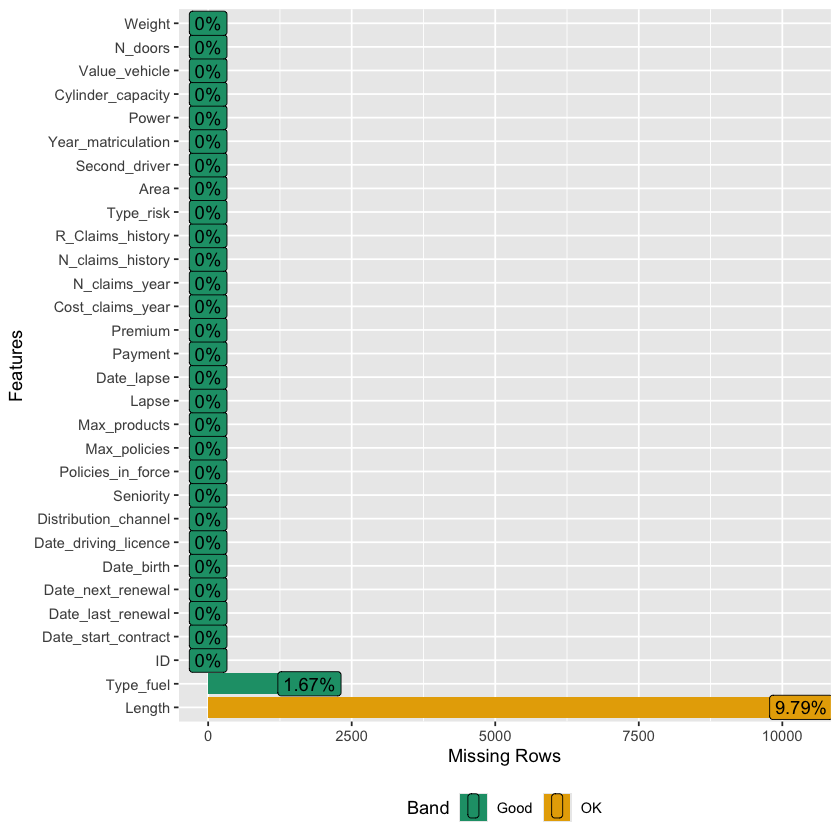

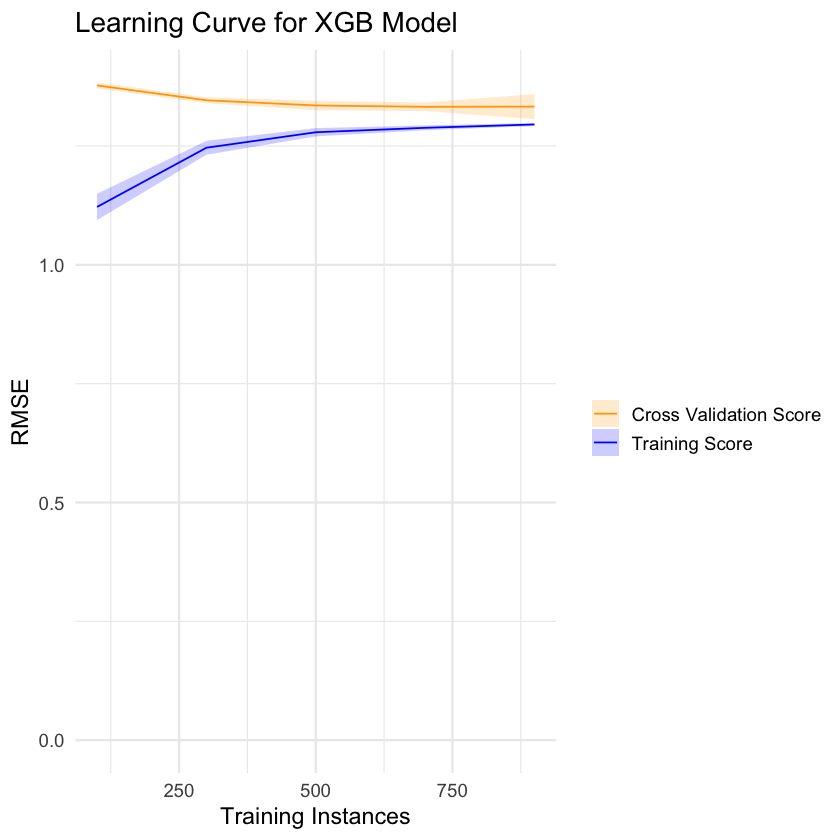

`geom_smooth()` using formula = 'y ~ x'


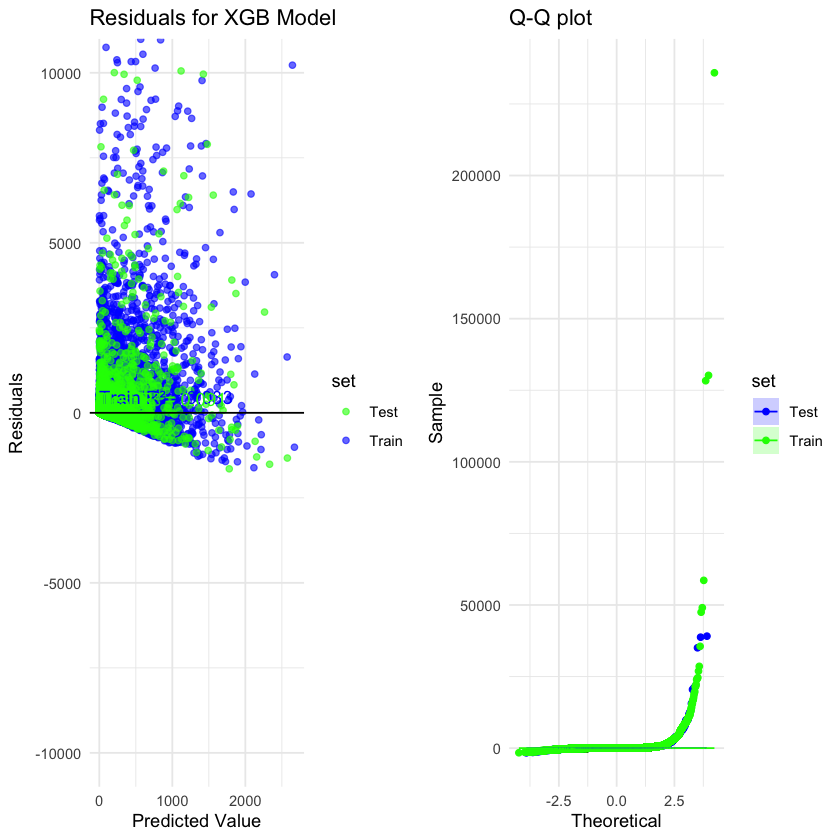

Preparation of a new explainer is initiated
  -> model label       :  R6  (  default  )
  -> data              :  53502  rows  26  cols 
  -> target variable   :  53502  values 
  -> predict function  :  yhat.LearnerRegr  will be used (  default  )
  -> predicted values  :  No value for predict function target column. (  default  )
  -> model_info        :  package mlr3 , ver. 0.23.0 , task regression (  default  ) 
  -> predicted values  :  numerical, min =  -0.365227 , mean =  1.514384 , max =  7.891063  
  -> residual function :  difference between y and yhat (  default  )
  -> residuals         :  numerical, min =  -5.227032 , mean =  -0.001770101 , max =  7.660663  
  A new explainer has been created!  


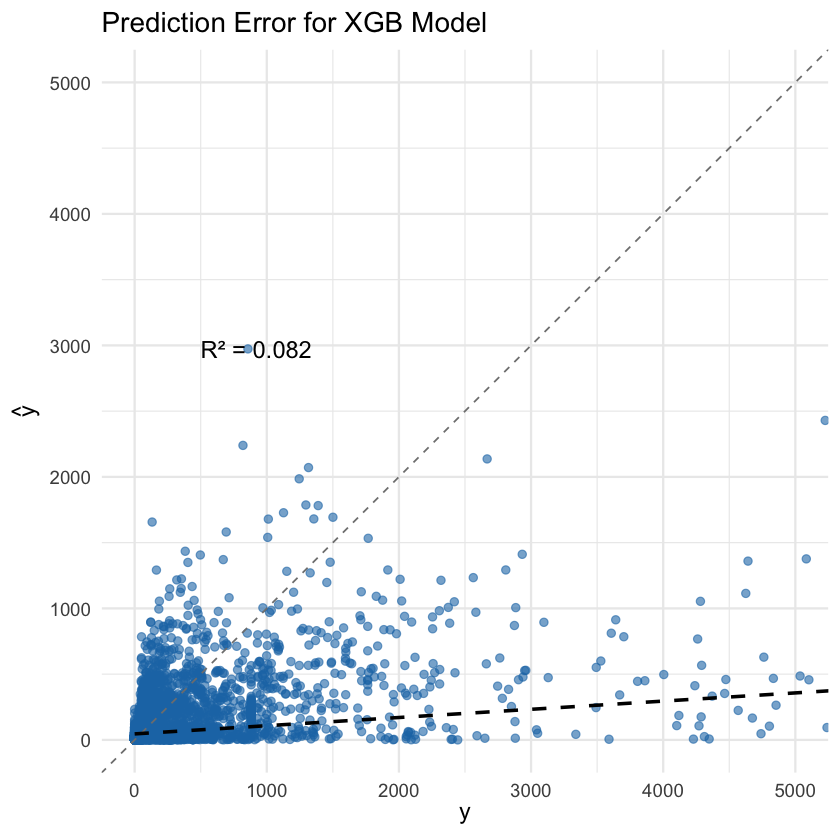

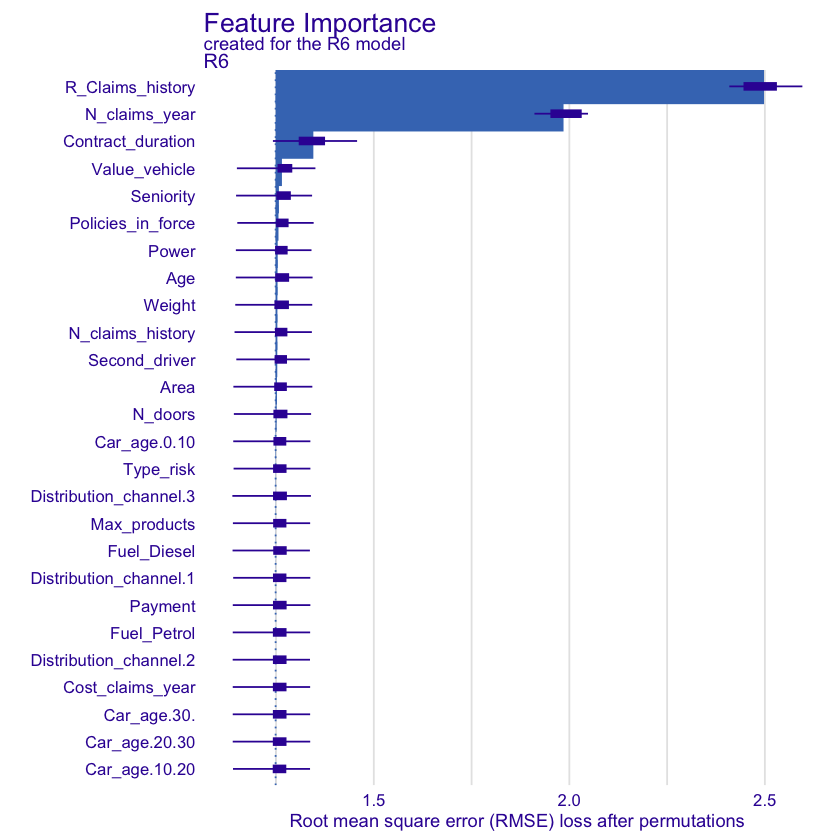

[1] "Age"                    "Area"                   "Contract_duration"     
 [4] "Fuel_Diesel"            "Fuel_Petrol"            "Max_products"          
 [7] "N_claims_history"       "N_claims_year"          "N_doors"               
[10] "Payment"                "Policies_in_force"      "Power"                 
[13] "R_Claims_history"       "Second_driver"          "Seniority"             
[16] "Type_risk"              "Value_vehicle"          "Weight"                
[19] "Car_age.0.10"           "Car_age.10.20"          "Car_age.20.30"         
[22] "Car_age.30."            "Distribution_channel.1" "Distribution_channel.2"
[25] "Distribution_channel.3"

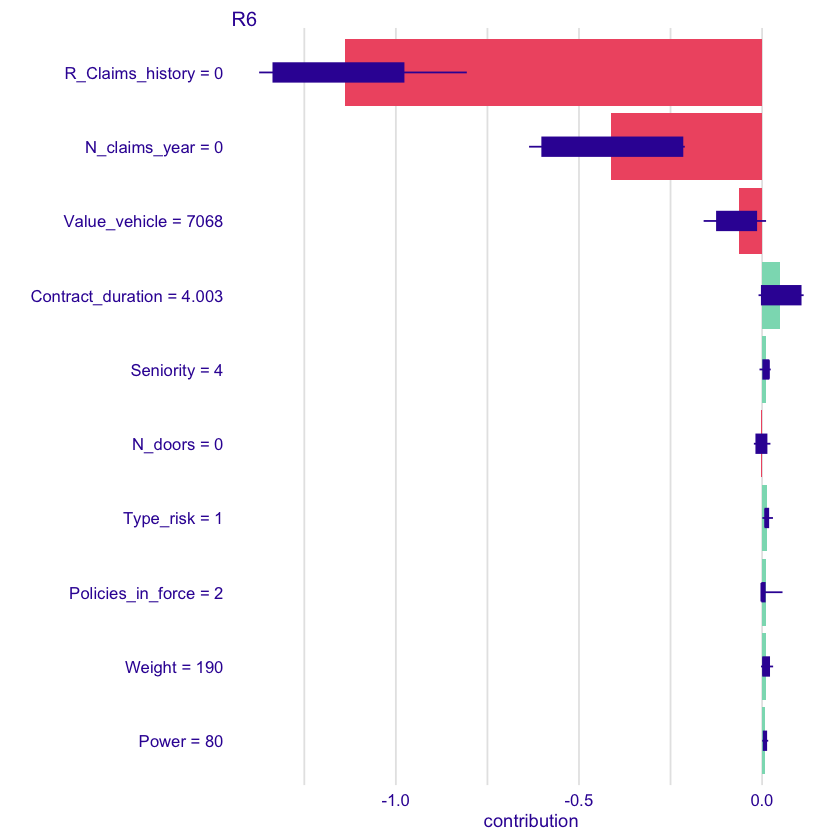

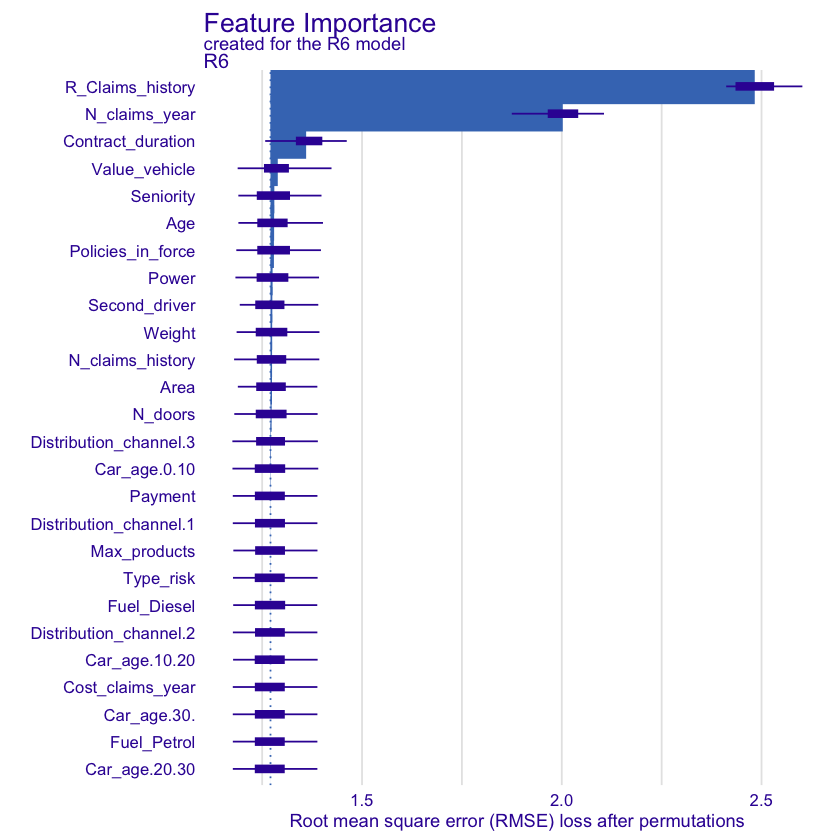

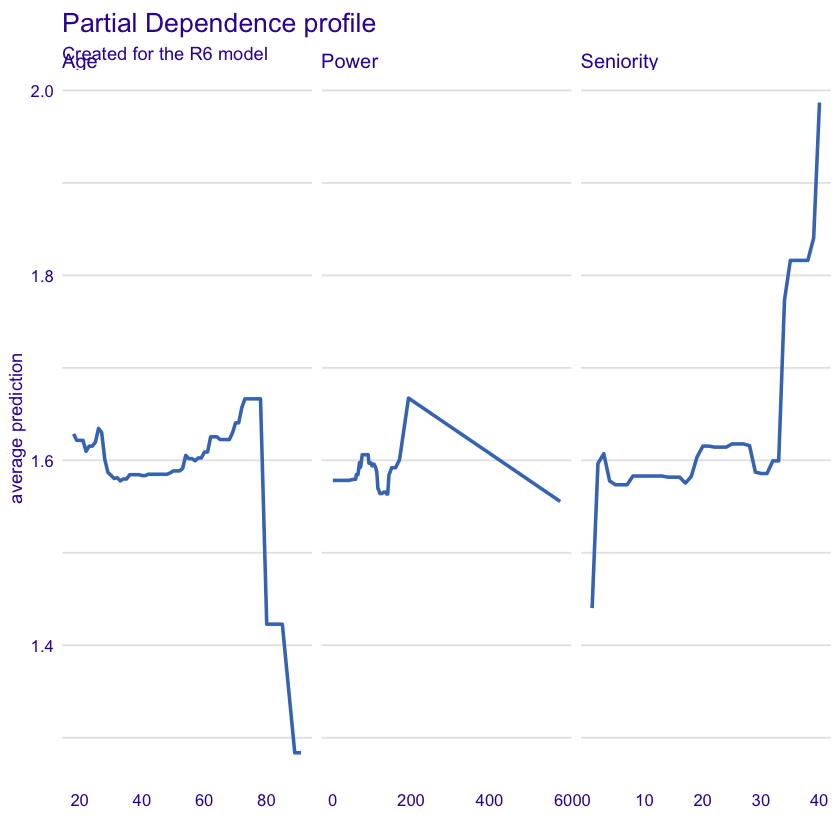

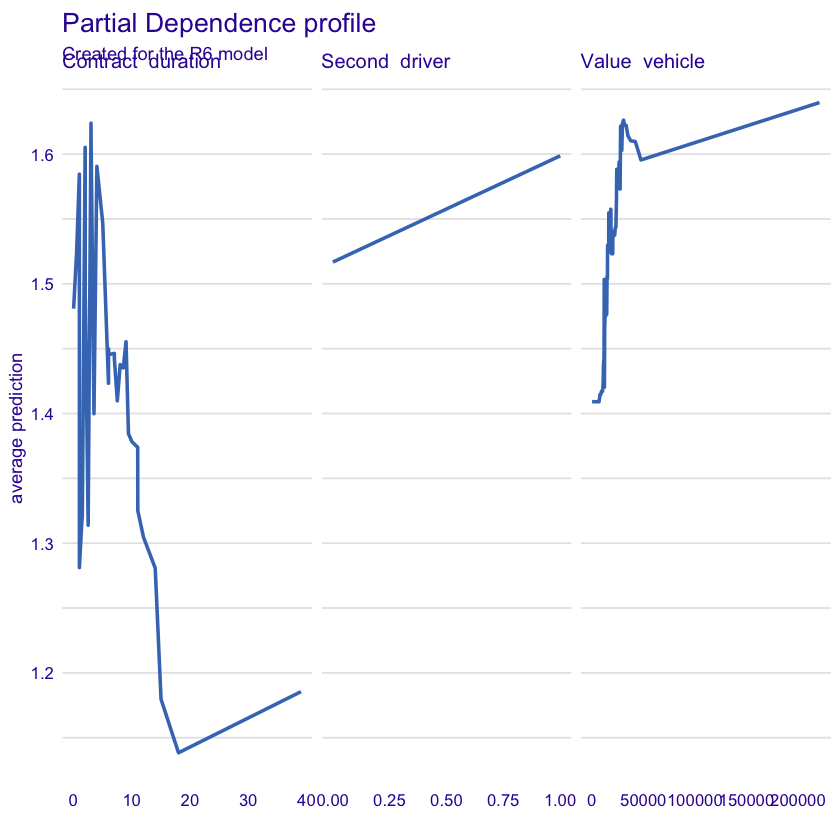

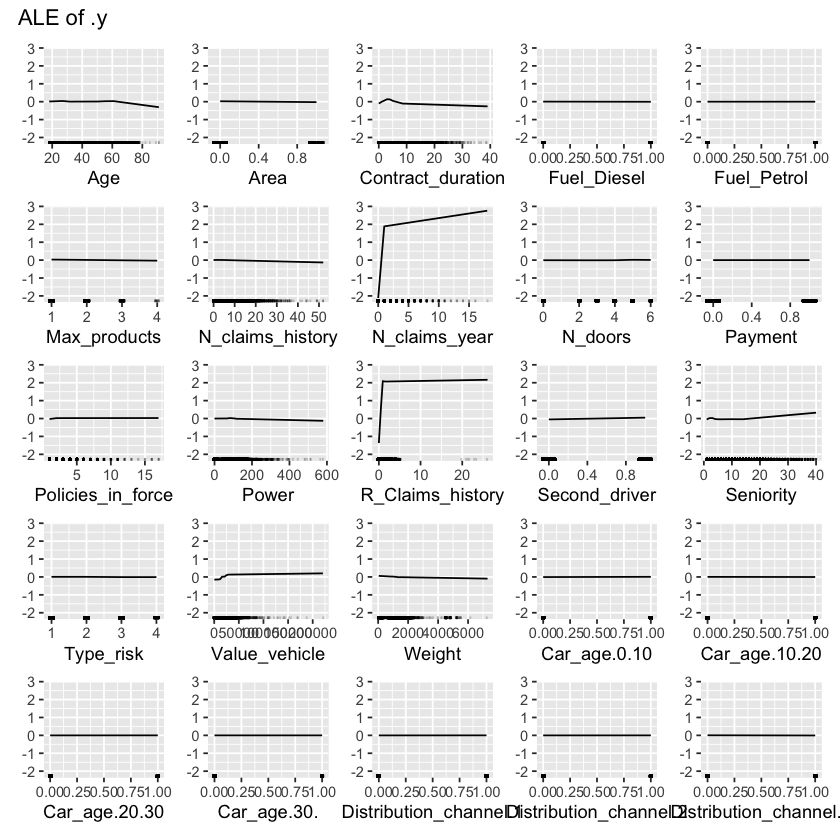

In [28]:
# --------------------------------------------------------------------------
# Libraries
# --------------------------------------------------------------------------
install.packages("skimr")
install.packages("DataExplorer")
install.packages("corrplot")
install.packages(c("mlr3verse", "mlr3", "mlr3learners", "mlr3pipelines", 
                   "mlr3viz", "mlr3tuning", "DALEX", "iml"))

install.packages("mlr3")
install.packages("mlr3tuning")
install.packages("mlr3learners")
install.packages("mlr3pipelines")
install.packages("paradox")
install.packages("DALEX")
install.packages("DALEXtra") 
install.packages("ggpubr")  
install.packages("gridExtra")
install.packages("shapper")

library(shapper)
library(gridExtra)
library(ggpubr) 
library(DALEXtra)
library(data.table)
library(tidyverse)
library(skimr)
library(DataExplorer)
library(lubridate)
library(corrplot)
library(ggplot2)
library(mlr3)
library(mlr3verse)
library(mlr3tuning)
library(mlr3learners)
library(mlr3viz)
library(xgboost)
library(DALEX)
library(iml)


# --------------------------------------------------------------------------
# Loading Data
# --------------------------------------------------------------------------


data <- read.csv("Dataset of an actual motor vehicle insurance portfolio/Motor vehicle insurance data.csv", sep = ";")



glimpse(data)

#skim(data)

plot_missing(data)
# --------------------------------------------------------------------------
# Preprocessing Data
# --------------------------------------------------------------------------
# Cleaning
# --------------------------------------------------------------------------
data <- data %>%
  mutate(
    Date_start_contract = dmy(Date_start_contract),
    Date_last_renewal = dmy(Date_last_renewal),
    Date_next_renewal = dmy(Date_next_renewal),
    Date_birth = dmy(Date_birth),
    Date_driving_licence = dmy(Date_driving_licence),
    Date_lapse = ifelse(Date_lapse == "", NA, Date_lapse),
    Date_lapse = dmy(Date_lapse),
    
    Distribution_channel = as.factor(Distribution_channel),
  )

str(data)

preprocess_data <- function(data) {
  df_processed <- data %>%
    
    # date of birth → age
    mutate(Age = as.integer(floor(interval(Date_birth, Date_start_contract) / years(1)))) %>%
    
    # Lapse → Nan → 0
    mutate(Lapse = ifelse(is.na(Lapse), 0, Lapse)) %>%
    
    # Date_lapse → Time remained until the end of contract
    mutate(
      Lapse_duration_days = as.numeric(Date_lapse - Date_start_contract)
    ) %>%
    
    mutate(
      Lapse_duration_days = ifelse(Lapse == 0, 0, Lapse_duration_days),
      Has_lapsed = ifelse(Lapse == 0, 0, 1)
    ) %>%
    
    mutate(
      Lapse_duration_days = replace_na(Lapse_duration_days, 0),
      Has_lapsed = replace_na(Has_lapsed, 0)) %>%
    
    # car_age as groups
    mutate(Car_age = cut(
      as.integer(year(Date_start_contract)) - as.integer(Year_matriculation),
      breaks = c(-Inf, 10, 20, 30, Inf),
      labels = c("0-10", "10-20", "20-30", "30+"),
      right = FALSE
    )) %>%
    
    group_by(Type_risk) %>%
    mutate(Type_fuel = ifelse(is.na(Type_fuel),
                              names(sort(table(Type_fuel), decreasing = TRUE))[1],
                              Type_fuel)) %>%
    ungroup() %>%
    mutate(
      Fuel_Petrol = ifelse(Type_fuel == "P", 1, 0),
      Fuel_Diesel = ifelse(Type_fuel == "D", 1, 0)
    ) %>%
    
    mutate(Distribution_channel = ifelse(is.na(Distribution_channel), "Missing", Distribution_channel)) %>%
    mutate(Distribution_channel = as.factor(Distribution_channel)) %>%
    
    # Length
    group_by(Type_risk) %>%
    mutate(
      Length = ifelse(is.na(Length), mean(Length, na.rm = TRUE), Length)
    ) %>%
    ungroup()
  
  return(df_processed)
}

processed_df <- preprocess_data(data)
head(processed_df)

#skim(processed_df)

df_weighted <- processed_df %>%
  mutate(Duration_days = pmin(Date_next_renewal, Date_lapse, na.rm = TRUE) - Date_start_contract) %>%
  mutate(Contract_duration = Duration_days / 365)

names(df_weighted)

get_mode <- function(x) {
  ux <- unique(x)
  ux[which.max(tabulate(match(x, ux)))]
}

df_agg <- df_weighted %>%
  group_by(ID) %>%
  summarise(
    Cost_claims_year = weighted.mean(Cost_claims_year, as.numeric(Contract_duration), na.rm = TRUE),
    Age = first(Age),
    Seniority = last(Seniority),
    Policies_in_force = last(Policies_in_force),
    Max_products = max(Max_products),
    Payment = get_mode(Payment),
    N_claims_year = last(N_claims_year),
    N_claims_history = last(N_claims_history),
    R_Claims_history = mean(R_Claims_history),
    Contract_duration = last(Contract_duration),
    Car_age = first(Car_age),
    Fuel_Petrol = max(Fuel_Petrol),
    Fuel_Diesel = max(Fuel_Diesel),
    Distribution_channel = first(Distribution_channel),
    Type_risk = first(Type_risk),
    Area = first(Area),
    Second_driver = max(Second_driver),
    Power = mean(Power, na.rm = TRUE),
    Value_vehicle = mean(Value_vehicle, na.rm = TRUE),
    Weight = mean(Weight, na.rm = TRUE),
    N_doors = first(N_doors)
  ) %>%
  ungroup()

head(df_agg)

#skim(df_agg)

df_model <- df_agg

set.seed(42)
df_model <- df_agg %>% select(-ID)
df_model$Cost_claims_year <- as.numeric(df_model$Cost_claims_year)
df_model <- df_model %>%
  mutate(across(where(~ inherits(.x, "difftime")), as.numeric))

head(df_model)



#----------------------------------------------------------------------------
#train-test split and model
#----------------------------------------------------------------------------
df_model$Cost_claims_year <- as.numeric(df_model$Cost_claims_year)
df_model$Cost_claims_year <- log1p(df_model$Cost_claims_year)  # log(1 + x)


# Create regression task
task <- TaskRegr$new(id = "claims", backend = df_model, target = "Cost_claims_year")
split <- partition(task, ratio = 0.8)
## Preprocessing Pipeline
# Basic preprocessing: mean imputation + mode imputation + one-hot encoding
pipeline <- po("imputemean", affect_columns = selector_type("numeric")) %>>%
  po("imputemode", affect_columns = selector_type("factor")) %>>%
  po("encode", method = "one-hot")

# Apply the pipeline to the task
task_prep <- pipeline$train(task)[[1]]

## Define Interpretable XGBoost Learner
learner_xgb <- lrn(
  "regr.xgboost", 
  id = "XGBoost_Interpretable",
  eta = 0.104,
  max_depth = 4,         # Interpretable tree
  nrounds = 117,
  subsample = 0.73,
  colsample_bytree = 0.98
)


learner_xgb$train(task_prep, row_ids = split$train)

# Predict on training data
prediction <- learner_xgb$predict(task_prep, row_ids = split$test)

# Evaluate RMSE
prediction$score(msr("regr.rmse"))

preds <- expm1(prediction$response)
actuals <- expm1(prediction$truth)
rmse_value <- sqrt(mean((preds - actuals)^2))
cat("RMSE:", rmse_value, "\n")

# --------------------------------------------------------------------------
# Baseline Model: Predict Mean of Cost_claims_year
# --------------------------------------------------------------------------
baseline_pred <- rep(mean(expm1(df_model$Cost_claims_year)), nrow(df_model))
baseline_actual <- expm1(df_model$Cost_claims_year)

# Calculate RMSE and MAE for baseline
baseline_rmse <- sqrt(mean((baseline_actual - baseline_pred)^2))

cat("Baseline RMSE:", baseline_rmse, "\n")



#----------------------------------------------------------------------------
#Global Explanation
#----------------------------------------------------------------------------
#----------------------------------------------------------------------------
# Learning Curve
#----------------------------------------------------------------------------



# Define the learner again
learner <- learner_xgb

# Define a sequence of training sizes
train_sizes <- seq(0.1, 0.9, by = 0.2) 

train_scores <- c()
val_scores <- c()
train_std <- c()
val_std <- c()

set.seed(42)
for (size in train_sizes) {
  scores <- replicate(10, {  # Repeat to get variance
    split <- partition(task_prep, ratio = size)
    
    learner$train(task_prep, row_ids = split$train)
    
    pred_train <- learner$predict(task_prep, row_ids = split$train)
    pred_val <- learner$predict(task_prep, row_ids = split$test)
    
    train_score <- pred_train$score(msr("regr.rmse"))
    val_score <- pred_val$score(msr("regr.rmse"))
    
    c(train_score, val_score)
  })
  
  train_scores <- c(train_scores, mean(scores[1, ]))
  val_scores <- c(val_scores, mean(scores[2, ]))
  train_std <- c(train_std, sd(scores[1, ]))
  val_std <- c(val_std, sd(scores[2, ]))
}

# Make data frame for plotting
df_lc <- data.frame(
  TrainingSize = train_sizes * 1000,  # Adjust depending on your dataset
  TrainingScore = train_scores,
  ValidationScore = val_scores,
  TrainSD = train_std,
  ValSD = val_std
)

# Plot learning curve
ggplot(df_lc, aes(x = TrainingSize)) +
  geom_line(aes(y = TrainingScore, color = "Training Score")) +
  geom_ribbon(aes(ymin = TrainingScore - TrainSD, ymax = TrainingScore + TrainSD, fill = "Training Score"), alpha = 0.2) +
  geom_line(aes(y = ValidationScore, color = "Cross Validation Score")) +
  geom_ribbon(aes(ymin = ValidationScore - ValSD, ymax = ValidationScore + ValSD, fill = "Cross Validation Score"), alpha = 0.2) +
  scale_color_manual(name = "", values = c("Training Score" = "blue", "Cross Validation Score" = "orange")) +
  scale_fill_manual(name = "", values = c("Training Score" = "blue", "Cross Validation Score" = "orange")) +
  coord_cartesian(ylim = c(0, NA)) +  # avoid negative scores
  labs(
    title = "Learning Curve for XGB Model",
    x = "Training Instances",
    y = "RMSE"
  ) +
  theme_minimal(base_size = 14)

#----------------------------------------------------------
# Residual Plot (Model Performace Explanation)
#----------------------------------------------------------
# ---- Step 1: Predict on both train and test sets
pred_train <- learner_xgb$predict(task_prep, row_ids = split$train)
pred_test  <- learner_xgb$predict(task_prep, row_ids = split$test)

# ---- Step 2: Back-transform predictions and truths
df_train <- data.frame(
  set = "Train",
  pred = expm1(pred_train$response),
  actual = expm1(pred_train$truth)
)

df_test <- data.frame(
  set = "Test",
  pred = expm1(pred_test$response),
  actual = expm1(pred_test$truth)
)

# ---- Step 3: Combine & calculate residuals
df_all <- bind_rows(df_train, df_test) %>%
  mutate(residual = actual - pred)

# ---- Step 4: Compute R² for each set
r2_train <- 1 - sum((df_train$pred - df_train$actual)^2) / sum((df_train$actual - mean(df_train$actual))^2)
r2_test  <- 1 - sum((df_test$pred - df_test$actual)^2) / sum((df_test$actual - mean(df_test$actual))^2)

# ---- Step 5: Plot residual plot with both sets
x_pos <- quantile(df_all$pred, 0.05)
y_pos <- quantile(df_all$residual, 0.95)
p1 <- ggplot(df_all, aes(x = pred, y = residual, color = set)) +
  geom_point(alpha = 0.6) +
  geom_hline(yintercept = 0, linetype = "solid") +
  scale_color_manual(values = c("Train" = "blue", "Test" = "green")) +
  labs(
    title = "Residuals for XGB Model",
    x = "Predicted Value",
    y = "Residuals"
  ) +
  annotate("text", x = x_pos, y = y_pos, 
           label = paste0("Train R² = ", round(r2_train, 3)), color = "blue", hjust = 0) +
  annotate("text", x = x_pos, y = y_pos * 0.9, 
           label = paste0("Test R² = ", round(r2_test, 3)), color = "green", hjust = 0) +
  coord_cartesian(ylim = c(-10000, 10000))+
  theme_minimal()

# ---- Step 6: Q-Q plot for both
library(ggpubr)
p2 <- ggqqplot(df_all, x = "residual", color = "set", palette = c("blue", "green")) +
  labs(title = "Q-Q plot") +
  theme_minimal()

# ---- Step 7: Combine plots
library(gridExtra)
grid.arrange(p1, p2, ncol = 2)



#--------------------------------------------------------
# prediction error plot
#--------------------------------------------------------
r2 <- 1 - sum((actuals - preds)^2) / sum((actuals - mean(actuals))^2)
r2_label <- paste0("R² = ", round(r2, 3))
# Create dataframe
df_pred <- data.frame(y = actuals, y_hat = preds)

# Plot
ggplot(df_pred, aes(x = y, y = y_hat)) +
  geom_point(alpha = 0.6, color = "#1f77b4", size = 2) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "gray50") +
  geom_smooth(method = "lm", se = FALSE, linetype = "dashed", color = "black") +
  annotate("text", x = 500, y = max(preds), label = r2_label, hjust = 0, size = 5) +
  coord_cartesian(xlim = c(0, 5000), ylim = c(0, 5000)) +  # Adjust zoom
  labs(
    title = "Prediction Error for XGB Model",
    x = expression(y),
    y = expression(hat(y))
  ) +
  theme_minimal(base_size = 14)


#--------------------------------------------------------
# Feature Importance (SHAP summary plot)
#--------------------------------------------------------
explainer <- explain_mlr3(learner_xgb, data = task_prep$data(), y = task_prep$truth())
importance <- model_parts(explainer)
plot(importance)

shap_values <- predict_parts(
  explainer,
  new_observation = task_prep$data(),  # all rows
  type = "shap",
  B = 10  # Number of permutations (can increase for better approximation)
)
plot(shap_values)




# --------------------------------------------------------------------------
# iml predictor object

# Get the data used for prediction
data_iml <- task_prep$data(cols = task_prep$feature_names)

# Wrap model and data into Predictor
predictor <- Predictor$new(
  model = learner_xgb,
  data = data_iml,
  y = task_prep$truth()
)

colnames(predictor$data$X)


# --------------------------------------------------------------------------
# Model Interpretation with DALEX
# --------------------------------------------------------------------------
# explainer <- explain_mlr3(learner_xgb, data = task_prep$data(), y = task_prep$truth())
importance <- model_parts(explainer)
plot(importance)


# Feature Effects
feature_effects <- model_profile(explainer, variables = c("Age", "Seniority", "Power"))
plot(feature_effects)

feature_effects2 <- model_profile(explainer, variables = c("Contract_duration", "Value_vehicle", "Second_driver"))
plot(feature_effects2)

effs <- FeatureEffects$new(predictor, grid.size = 10)
plot(effs)





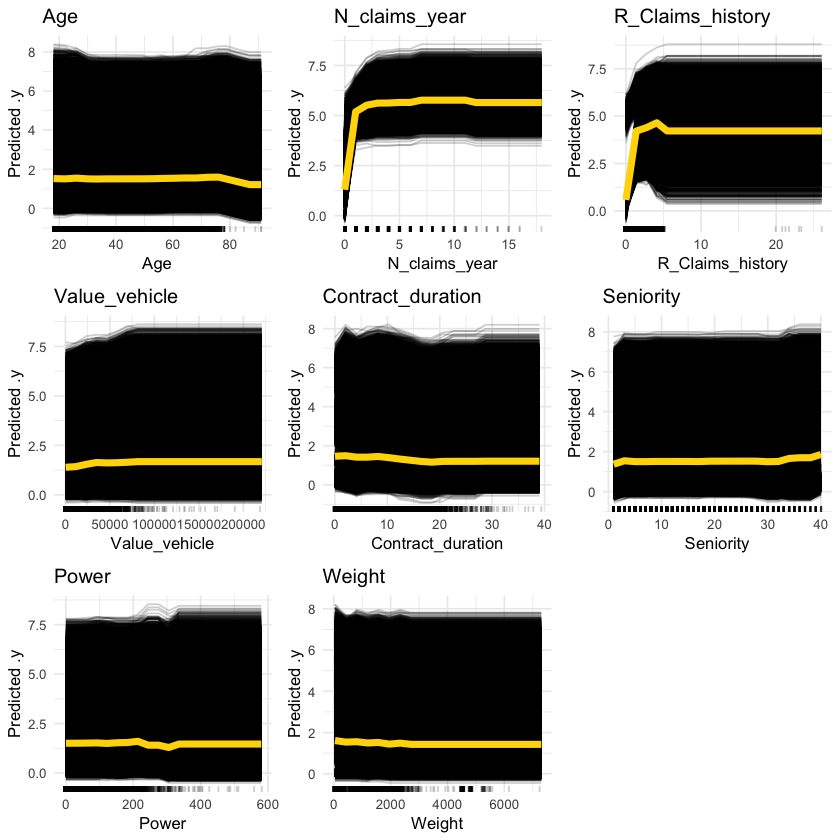

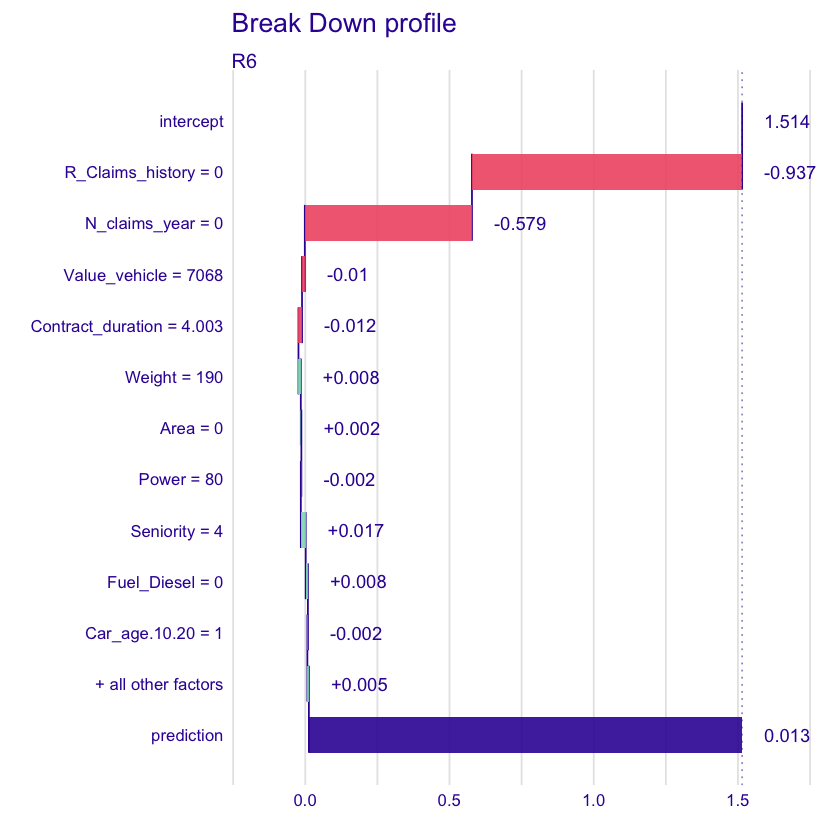

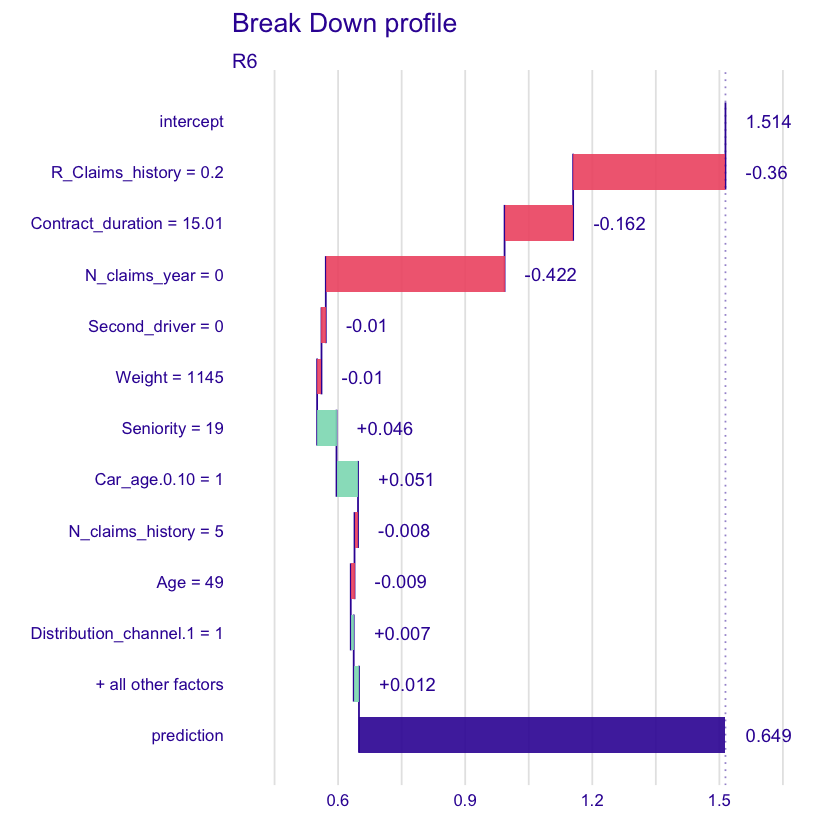

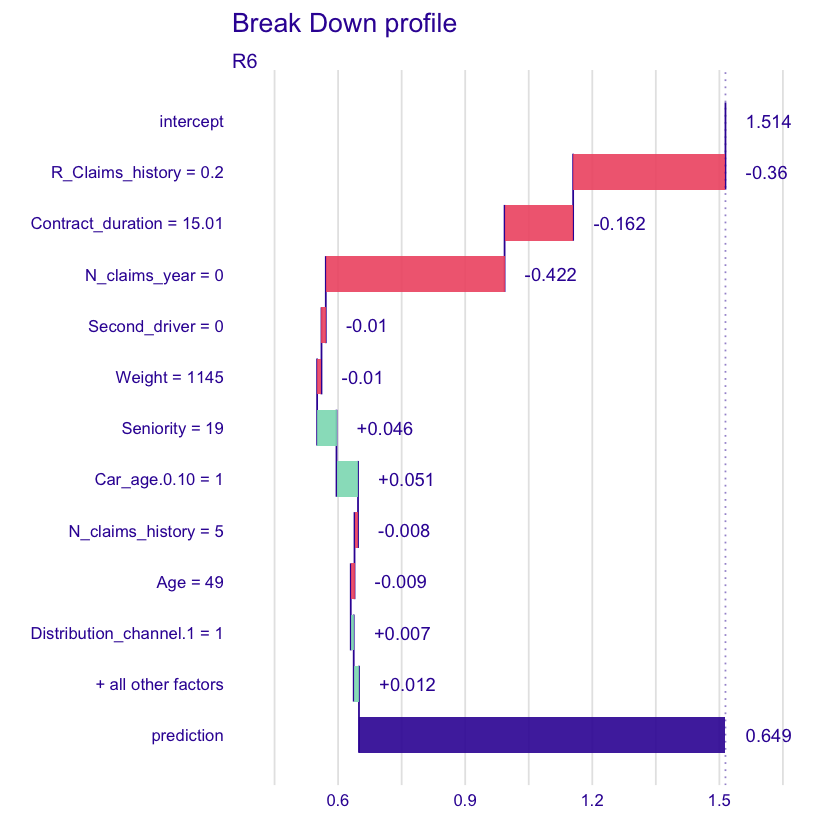

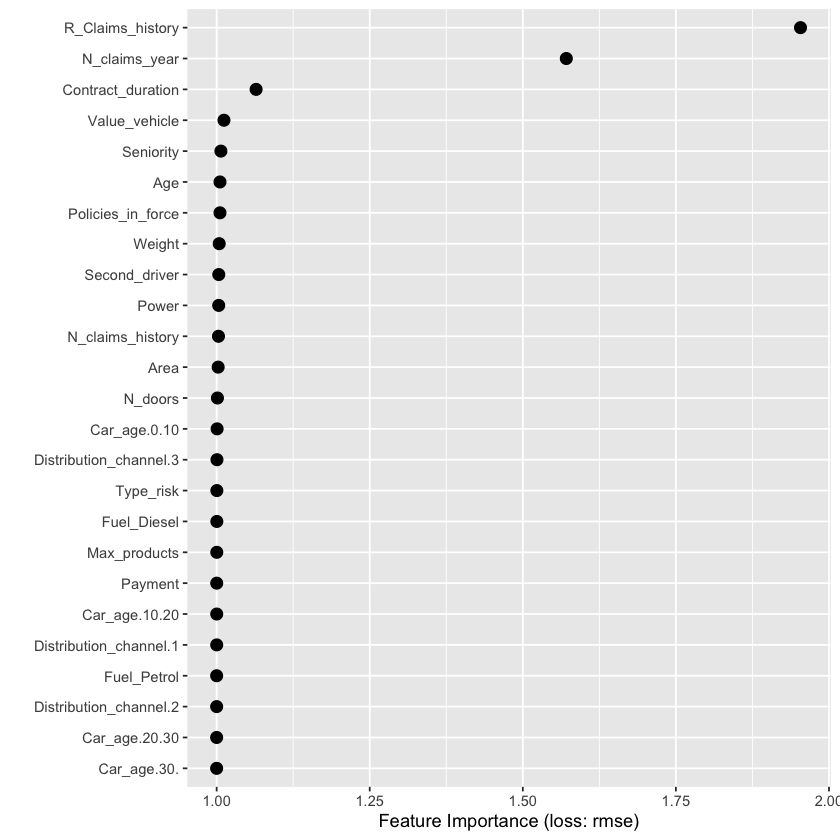

In [29]:


#--------------------------------------------------------
# ICE plots
#--------------------------------------------------------
features_to_plot <- c(
  "Age", 'N_claims_year', "R_Claims_history", "Value_vehicle",
  "Contract_duration", "Seniority", "Power", "Weight"
)

# List to store plots
plots <- list()

# Loop over features
for (f in features_to_plot) {
  fe <- FeatureEffect$new(
    predictor, feature = f, method = "pdp+ice", grid.size = 20
  )
  p <- fe$plot() +
    ggtitle(f) +
    theme_minimal(base_size = 10)
  plots[[f]] <- p
}

# Arrange in a 3x3 grid
grid.arrange(grobs = plots, ncol = 3)


# --------------------------------------------------------------------------
# Local Explanations (Shapley Values)
# --------------------------------------------------------------------------
# Take one row from your dataset
shap_local <- predict_parts(explainer, new_observation = task_prep$data()[1,])
plot(shap_local)

shap_local2 <- predict_parts(explainer, new_observation = task_prep$data()[16,])
plot(shap_local2)

# Local explanation for a specific observation
obs <- task_prep$data()[8,]  # Try a different row
shap_local3 <- predict_parts(explainer, new_observation = obs)
plot(shap_local2)

# Permutation feature importance
imp <- FeatureImp$new(predictor, loss = "rmse")
plot(imp)
 


------------------------------------------------------------------------------


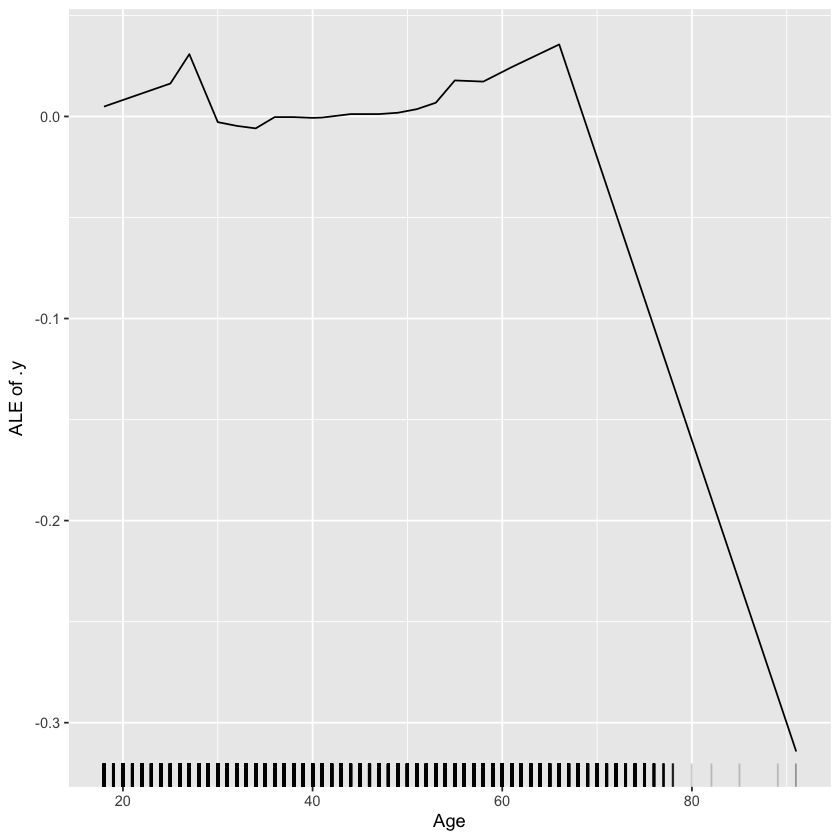

In [30]:

# ALE 
effect_ale = FeatureEffect$new(predictor, feature = "Age", method = "ale")
effect_ale$plot()


In [31]:
df_rmse_test <- task_prep$data()
df_no_age <- df_rmse_test[, !("Age"), drop = FALSE]

task_no_age <- TaskRegr$new(id = "no_age", backend = df_no_age, target = "Cost_claims_year")
task_no_age_prep <- pipeline$train(task_no_age)[[1]]

learner_xgb$train(task_no_age_prep, row_ids = split$train)
prediction_no_age <- learner_xgb$predict(task_no_age_prep, row_ids = split$test)
prediction_no_age$score(msr("regr.rmse"))

cor_matrix <- cor(df_model %>% select(where(is.numeric)), use = "pairwise.complete.obs")
sort(cor_matrix["Age", ], decreasing = TRUE)




regr.rmse 
 1.331266

Age     Second_driver Policies_in_force      Max_products 
      1.000000000       0.130828564       0.084520997       0.063655256 
           Weight     Value_vehicle       Fuel_Petrol           N_doors 
      0.023353444       0.014069854       0.009447183       0.007546458 
        Seniority  N_claims_history     N_claims_year       Fuel_Diesel 
     -0.001958354      -0.005393589      -0.006453192      -0.009447183 
 Cost_claims_year             Power  R_Claims_history              Area 
     -0.026889259      -0.027945636      -0.034299534      -0.034730754 
        Type_risk           Payment Contract_duration 
     -0.042645032      -0.086277762      -0.113698728

 Cost_claims_year               Age         Seniority Policies_in_force 
            -0.03              1.00              0.00              0.08 
     Max_products           Payment     N_claims_year  N_claims_history 
             0.06             -0.09             -0.01             -0.01 
 R_Claims_history Contract_duration       Fuel_Petrol       Fuel_Diesel 
            -0.03             -0.11              0.01             -0.01 
        Type_risk              Area     Second_driver             Power 
            -0.04             -0.03              0.13             -0.03 
    Value_vehicle            Weight           N_doors 
             0.01              0.02              0.01 


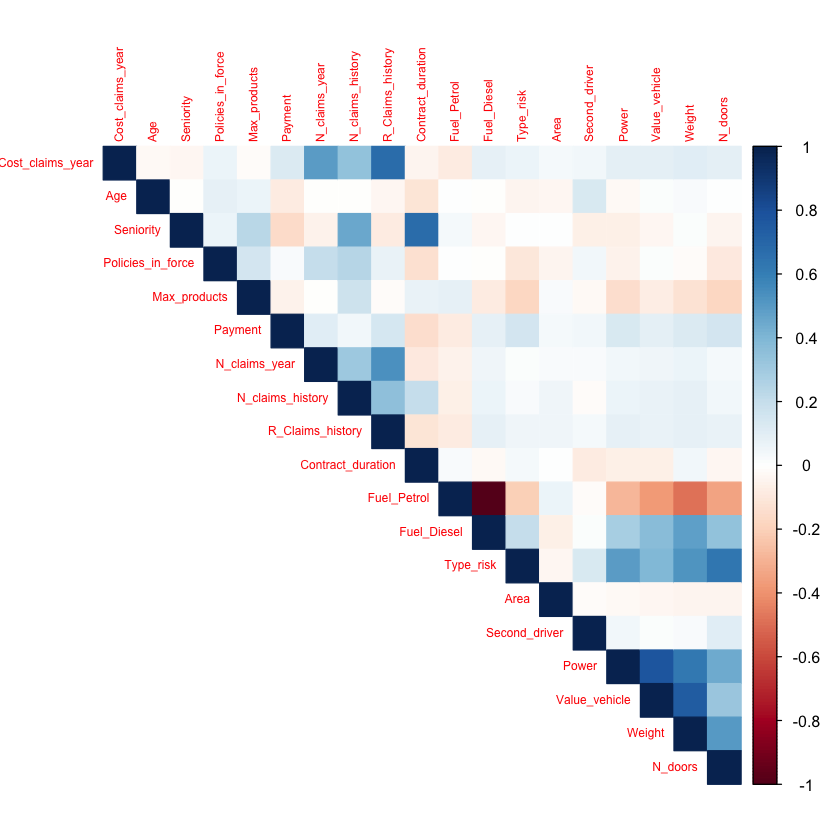

In [33]:
# Identify numeric columns
num_vars <- sapply(df_model, is.numeric)

# Compute correlation matrix for numeric columns
cor_matrix <- cor(df_model[, num_vars], use = "pairwise.complete.obs")

# Print correlations with "Age"
print(round(cor_matrix["Age", ], 2))

# Plot correlation matrix
corrplot::corrplot(cor_matrix, method = "color", type = "upper", tl.cex = 0.6)

# The only one correlatet is Driving experience and Car age and second driver ; threshold 0.1


Residaulization features:  Contract_duration, Second_driver 


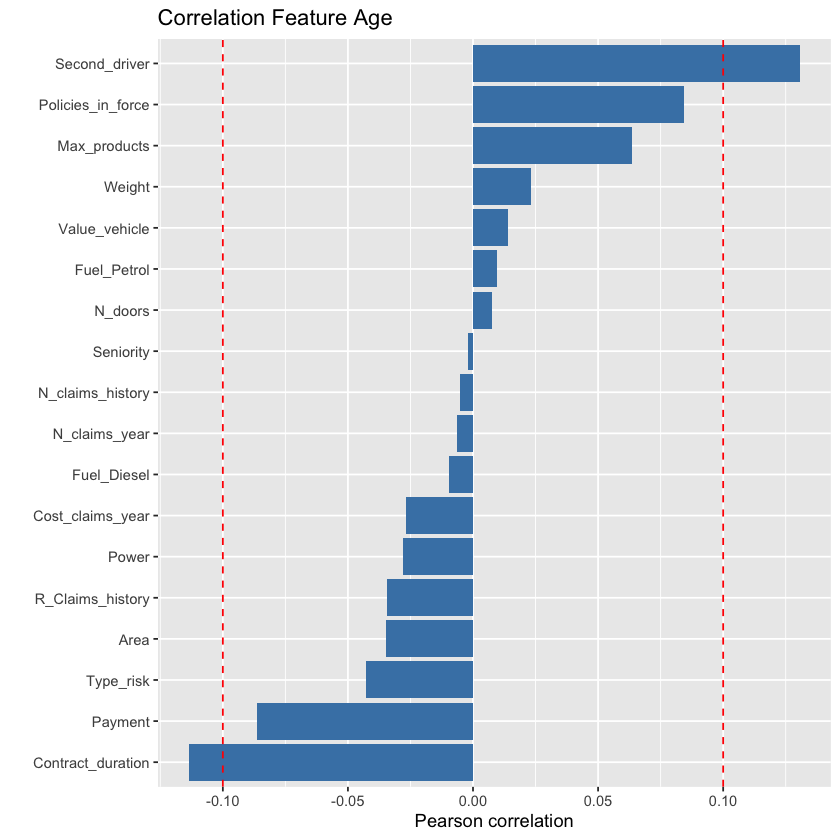

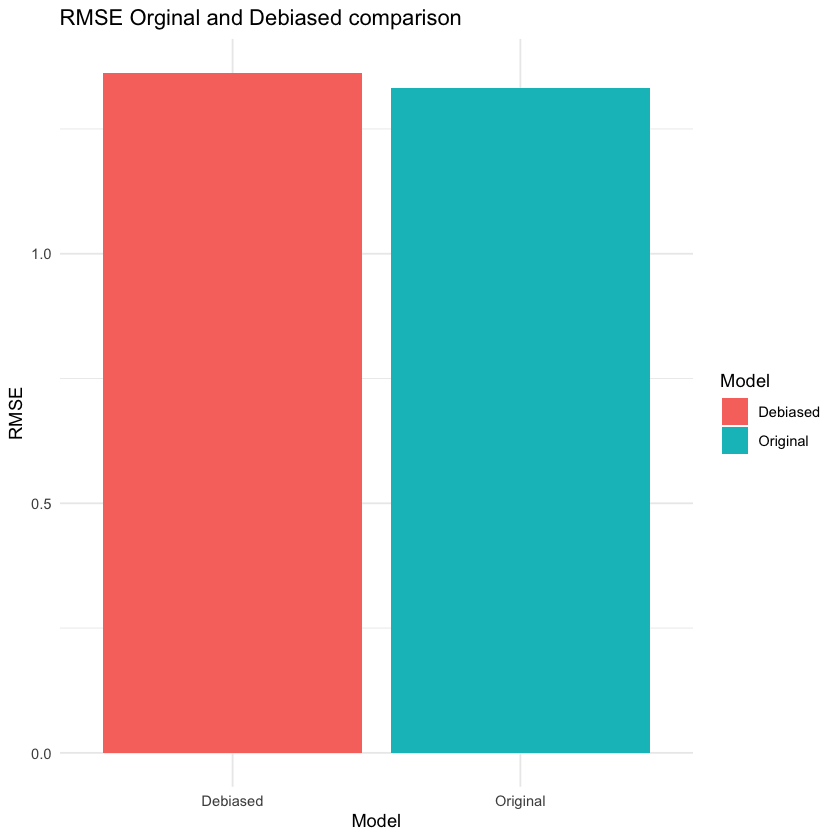

In [34]:
# --------------------------------------------------------------------------
# 1. Korelacje względem Age
# --------------------------------------------------------------------------

cor_vector <- cor(df_model %>% select(where(is.numeric)), use = "pairwise.complete.obs")["Age", ]
cor_vector <- cor_vector[!names(cor_vector) %in% c("Age")]

# Wizualizacja korelacji z Age
cor_df <- data.frame(Feature = names(cor_vector), Correlation = cor_vector)
library(ggplot2)
ggplot(cor_df, aes(x = reorder(Feature, Correlation), y = Correlation)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  geom_hline(yintercept = c(-0.1, 0.1), linetype = "dashed", color = "red") +
  labs(title = "Correlation Feature Age", x = "", y = "Pearson correlation")

# Wybranie zmiennych do residualizacji
vars_to_resid <- names(cor_vector[abs(cor_vector) >= 0.1])
vars_to_resid <- setdiff(vars_to_resid, "Car_age")

cat("Residaulization features: ", paste(vars_to_resid, collapse = ", "), "\n")

# --------------------------------------------------------------------------
# 2. Residualizacja
# --------------------------------------------------------------------------

residualize_on_age <- function(df, vars, age_var = "Age") {
  for (v in vars) {
    formula <- as.formula(paste(v, "~", age_var))
    df[[paste0(v, "_resid")]] <- residuals(lm(formula, data = df))
  }
  return(df)
}

df_debiased <- residualize_on_age(df_model, vars_to_resid)

# --------------------------------------------------------------------------
# 3. Usunięcie Age i oryginalnych zmiennych
# --------------------------------------------------------------------------

to_remove <- c("Age", vars_to_resid)
df_final_debiased <- df_debiased[, !(names(df_debiased) %in% to_remove)]

# --------------------------------------------------------------------------
# 4. Zadania mlr3 i pipeline
# --------------------------------------------------------------------------

# Zadanie dla modelu bazowego (z Age)
task_orig <- TaskRegr$new(id = "claims_orig", backend = df_model, target = "Cost_claims_year")
task_prep_orig <- pipeline$train(task_orig)[[1]]

# Zadanie dla modelu debiased
task_debiased <- TaskRegr$new(id = "claims_debiased", backend = df_final_debiased, target = "Cost_claims_year")
task_prep_debiased <- pipeline$train(task_debiased)[[1]]

# --------------------------------------------------------------------------
# 5. Trenowanie modeli
# --------------------------------------------------------------------------

learner_xgb$train(task_prep_orig, row_ids = split$train)
pred_orig <- learner_xgb$predict(task_prep_orig, row_ids = split$test)
rmse_orig <- pred_orig$score(msr("regr.rmse"))

learner_xgb$train(task_prep_debiased, row_ids = split$train)
pred_debiased <- learner_xgb$predict(task_prep_debiased, row_ids = split$test)
rmse_debiased <- pred_debiased$score(msr("regr.rmse"))

# --------------------------------------------------------------------------
# 6. Porównanie RMSE i wykresy
# --------------------------------------------------------------------------

rmse_df <- data.frame(
  Model = c("Original", "Debiased"),
  RMSE = c(rmse_orig, rmse_debiased)
)

ggplot(rmse_df, aes(x = Model, y = RMSE, fill = Model)) +
  geom_col() +
  labs(title = "RMSE Orginal and Debiased comparison", y = "RMSE") +
  theme_minimal()

# --------------------------------------------------------------------------
# 7. Różnice predykcji – histogram i boxplot
# --------------------------------------------------------------------------

pred_diff <- data.frame(
  Original = pred_orig$response,
  Debiased = pred_debiased$response,
  Truth = pred_debiased$truth
)

pred_diff$Difference <- pred_diff$Original - pred_diff$Debiased




In [ ]:
# --------------------------------------------------------------------------
# 7. Różnice predykcji – histogram i boxplot
# --------------------------------------------------------------------------

pred_diff <- data.frame(
  Original = pred_orig$response,
  Debiased = pred_debiased$response,
  Truth = pred_debiased$truth
)

pred_diff$Difference <- pred_diff$Original - pred_diff$Debiased
# Histogram
ggplot(pred_diff, aes(x = Difference)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "black") +
  labs(title = "Histogram of Prediction Differences", x = "Difference (Original - Debiased)", y = "Count") +
  theme_minimal()
# Boxplot
ggplot(pred_diff, aes(x = "", y = Difference)) +
  geom_boxplot(fill = "steelblue", color = "black") +
  labs(title = "Boxplot of Prediction Differences", x = "", y = "Difference (Original - Debiased)") +
  theme_minimal() +
  coord_flip() 







Pobrane pakiety binarne są w
	/var/folders/q7/p3s6dfbn0dv04bh3j4kgrz2c0000gn/T//RtmpqoHLve/downloaded_packages

Pobrane pakiety binarne są w
	/var/folders/q7/p3s6dfbn0dv04bh3j4kgrz2c0000gn/T//RtmpqoHLve/downloaded_packages


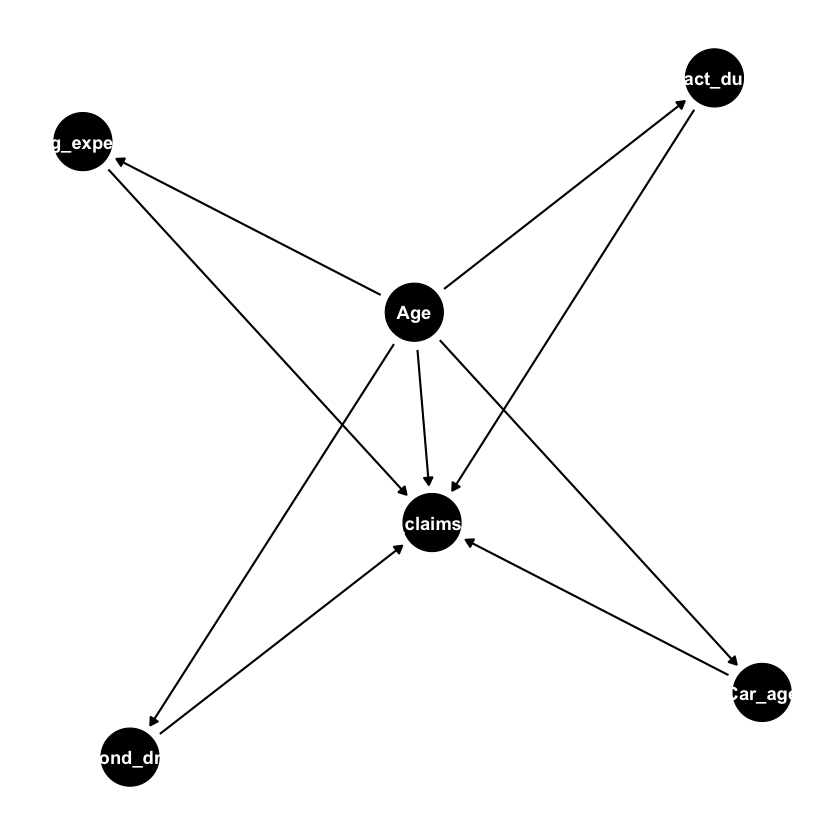

In [35]:

install.packages("dagitty")
install.packages("ggdag")
library(dagitty)
library(ggdag)

dag <- dagify(
  Cost_claims_year ~ Driving_experience + Second_driver + Car_age + Contract_duration + Age,
  Driving_experience ~ Age,
  Second_driver ~ Age,
  Car_age ~ Age,
  Contract_duration ~ Age,
  exposure = "Age",
  outcome = "Cost_claims_year"
)

ggdag(dag, text = TRUE) +
  theme_dag() +
  theme(text = element_text(size = 30))  # zwiększenie czytelności



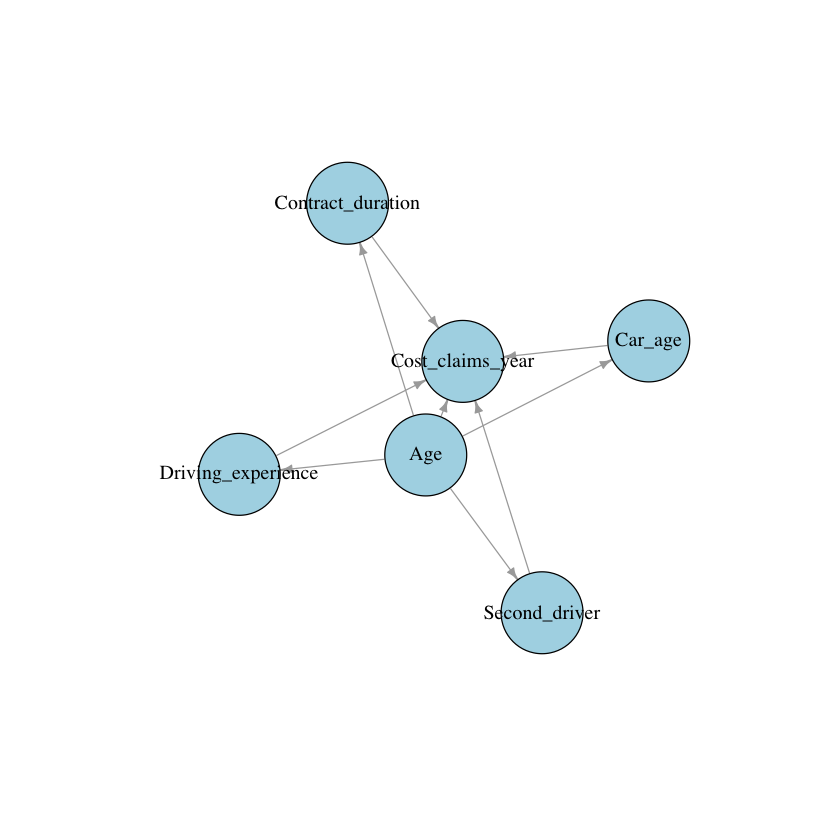

In [36]:
library(igraph)

edges <- matrix(c(
  "Age", "Driving_experience",
  "Age", "Second_driver",
  "Age", "Car_age",
  "Age", "Contract_duration",
  "Age", "Cost_claims_year",
  "Driving_experience", "Cost_claims_year",
  "Second_driver", "Cost_claims_year",
  "Car_age", "Cost_claims_year",
  "Contract_duration", "Cost_claims_year"
), byrow = TRUE, ncol = 2)

g <- graph_from_edgelist(edges, directed = TRUE)

plot(
  g,
  vertex.label.cex = 1.0,                     # większy rozmiar czcionki
  vertex.label.color = "black",              # czytelne etykiety
  vertex.size = 40,                          # większe koła
  vertex.color = "lightblue",
  edge.arrow.size = 0.5,
  layout = layout_with_fr,                   # lepszy layout (fruchterman)
  margin = c(0.2, 0.2, 0.2, 0.2)              # marginesy
)

